## PySpark Session Setup

We are using historical weather and wheat futures data to predict future trading volumes of wheat futures

In [1]:
##Install Pyspark
! pip install pyspark >& /dev/null

##Import Required Libraries
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, isnan, when, count, to_date, length, substring, regexp_replace
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import functions as F


##Start Session
spark = SparkSession.builder.appName("wheat_futures_price_prediction").getOrCreate()

25/04/24 19:45:46 WARN Utils: Your hostname, codespaces-db67ff resolves to a loopback address: 127.0.0.1; using 10.0.10.116 instead (on interface eth0)
25/04/24 19:45:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/24 19:45:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data Processing

In [2]:
###Read Weather and Priceing Datasets
weather_raw = spark.read.csv('weather_data_RAW.csv', header=True, inferSchema=True)
wheat_price_data = spark.read.csv('US_wheat_future_pricing_RAW.csv', header=True, inferSchema=True)

##Parse Date Column for consistant format
weather = weather_raw.withColumn(
    "Date",
    to_date(col("datetime"), "M/d/yyyy")      
).drop("datetime")                            

pricing = wheat_price_data.withColumn(
    "Date",
    to_date(col("Date"), "M/d/yyyy")        
)

##Merge on Date
merged = weather.join(pricing, on="Date", how="left")

##Clean Column Names
old_cols = merged.columns
new_cols = [c.replace('.', '').replace(' ', '_') for c in old_cols]
merged_clean = merged.toDF(*new_cols)

merged_clean.show(5)



25/04/24 19:46:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+----------+-------------------+-------------------+---------+--------------------+--------------------+-----------------+--------------------+------+------+------+------+------+--------+
|      Date| name|tempmax|tempmin|temp|feelslikemax|feelslikemin|feelslike| dew|humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|severerisk|            sunrise|             sunset|moonphase|          conditions|         description|             icon|            stations| Price|  Open|  High|   Low|   Vol|Change_%|
+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----

In [3]:

int_columns = ["Price", "Open", "High", "Low"] 
float_columns = ["Vol", "Change_%"]
##Type Casting
for col_name in int_columns:
   merged_clean = merged_clean.withColumn(col_name, col(col_name).cast("int"))
merged_clean = merged_clean.withColumn(
    "Vol",
    when(
        col("Vol").rlike("K$"),
        (regexp_replace(col("Vol"), "K", "").cast("float") * 1000).cast("string")
    ).otherwise(col("Vol"))
)
merged_clean = merged_clean.withColumn(
    "Change_%",
    when(
        col("Change_%").rlike("%$"),
        (regexp_replace(col("Change_%"), "%", "").cast("float")).cast("string")
    ).otherwise(col("Change_%"))
)

for col_name in float_columns:
    merged_clean = merged_clean.withColumn(col_name, col(col_name).cast("float"))

merged_clean = merged_clean.withColumnRenamed("Vol", "Volume").withColumnRenamed("Change_%", "Change")
merged_clean.printSchema()
print(f"The dataset contains {merged_clean.count()} rows and {len(merged_clean.columns)} columns.")


25/04/24 19:46:09 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


root
 |-- Date: date (nullable = true)
 |-- name: integer (nullable = true)
 |-- tempmax: double (nullable = true)
 |-- tempmin: double (nullable = true)
 |-- temp: double (nullable = true)
 |-- feelslikemax: double (nullable = true)
 |-- feelslikemin: double (nullable = true)
 |-- feelslike: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- precip: double (nullable = true)
 |-- precipprob: integer (nullable = true)
 |-- precipcover: double (nullable = true)
 |-- preciptype: string (nullable = true)
 |-- snow: double (nullable = true)
 |-- snowdepth: double (nullable = true)
 |-- windgust: double (nullable = true)
 |-- windspeed: double (nullable = true)
 |-- winddir: double (nullable = true)
 |-- sealevelpressure: double (nullable = true)
 |-- cloudcover: double (nullable = true)
 |-- visibility: double (nullable = true)
 |-- solarradiation: double (nullable = true)
 |-- solarenergy: double (nullable = true)
 |-- uvindex: integer 

The dataset contains 14616 rows and 39 columns.



EDA

In [4]:
##Check for Nulls
for column in merged_clean.columns:
    null_count = merged_clean.filter(F.col(column).isNull()).count()
    if null_count > 0:
        print(f"The column '{column}' has {null_count} null values.")

#remove unneeded cols
cols_to_drop = ["feelslikemax","feelslikemin","feelslike","severerisk","description","icon","stations"]
merged_clean=merged_clean.drop(*cols_to_drop)

##Exploratory Analysis on Numeric Columns
numeric_cols = [c for c, dtype in merged_clean.dtypes if dtype in ("float","integer", "double", "int")]
numeric_cols = [c for c in numeric_cols if c not in ["Date", "name"]]
merged_clean.describe(numeric_cols).show()

The column 'preciptype' has 7951 null values.
The column 'windgust' has 3 null values.
The column 'visibility' has 343 null values.
The column 'severerisk' has 9844 null values.
The column 'Price' has 4688 null values.
The column 'Open' has 4688 null values.
The column 'High' has 4700 null values.
The column 'Low' has 4672 null values.
The column 'Volume' has 4552 null values.
The column 'Change' has 4376 null values.


+-------+------------------+----------------+-----------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+
|summary|           tempmax|         tempmin|             temp|               dew|         humidity|             precip|        precipprob|       precipcover|               snow|         snowdepth|          windgust|        windspeed|           winddir|  sealevelpressure|        cloudcover|        visibility|    solarradiation|      solarenergy|           uvindex|         moonphase|             Price|              Open|              High|               Low|            Volume|             Change

In [ ]:
##Convert PySpark DataFrame to Pandas DataFrame for Data Visualization
pdf = merged_clean.sample(False, 0.1, seed=42).toPandas()
#Univariate histograms
for c in numeric_cols:
    sns.histplot(pdf[c].dropna(), kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.show()

#Boxplots of numeric features
sns.boxplot(data=pdf[numeric_cols])
plt.title("Boxplots of Numeric Features")
plt.show()

#Correlation heatmap
corr = pdf[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

#Scatterplot (temp vs. Price)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pdf, x='temp', y='Price', hue='Player', legend=False, s=50)
plt.title('Scatter Plot of PER vs. WS')
plt.xlabel('Player Efficiency Rating (PER)')
plt.ylabel('Win Shares (WS)')
plt.show()

#Time‑series of Price
if "Date" in pdf.columns and "Price" in pdf.columns:
    pdf["Date"] = pd.to_datetime(pdf["Date"])
    pdf = pdf.sort_values("Date")

    # raw line plot
    sns.lineplot(x="Date", y="Price", data=pdf)
    plt.title("Wheat Price Over Time")
    plt.show()


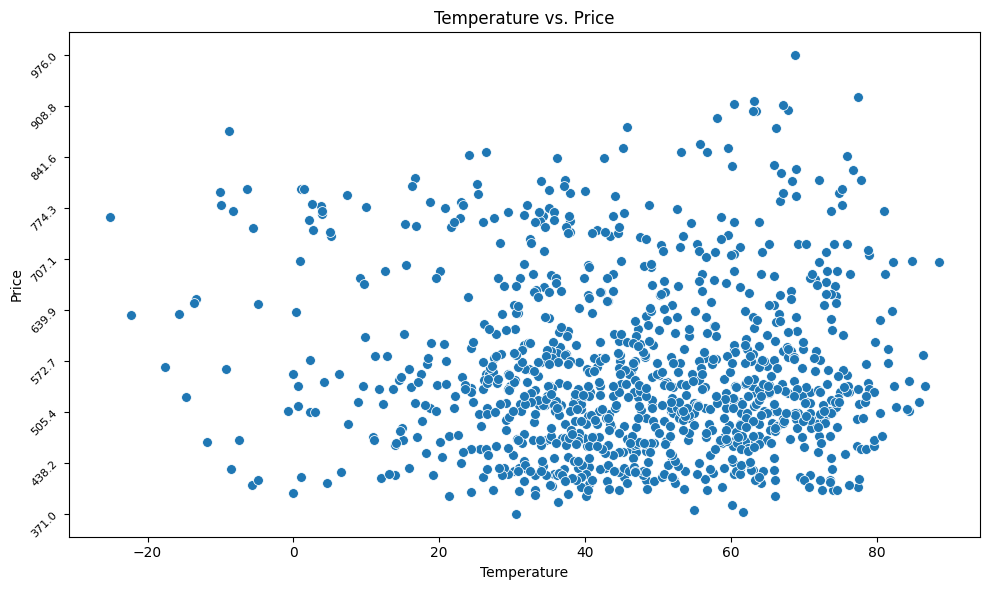

In [6]:
# assume pdf['Price'] may have strings
prices = pd.to_numeric(pdf['Price'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pdf, x='temp', y='Price', legend=False, s=50)
plt.title('Temperature vs. Price')
plt.xlabel('Temperature')
plt.ylabel('Price')

y_min, y_max = prices.min(), prices.max()
plt.yticks(np.linspace(y_min, y_max, 10), rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

Feature Engineering/Preprocessing Steps

In [5]:
from pyspark.sql.types import DataType
from pyspark.sql.functions import col
from pyspark.sql.functions import when, col, regexp_replace


#strip column names (remove dots/spaces)
old_cols   = merged.columns
new_cols   = [c.replace('.', '').replace(' ', '_') for c in old_cols]
merged_clean = merged.toDF(*new_cols)
merged_clean = merged_clean.withColumnRenamed("Vol", "Volume")
merged_clean = merged_clean.withColumnRenamed("Change_%", "Change")

merged_clean = merged_clean.withColumn(
    "Change",  
    regexp_replace(col("Change"), "%", "")
)

merged_clean = merged_clean.withColumn(
    "Volume",  
    regexp_replace(col("Volume"), "K", "")
)

merged_clean = merged_clean.withColumn(
    "Volume",
    col("Volume").cast("int")
)

merged_clean = merged_clean.withColumn(
    "Change",
    col("Change").cast("float")    
)

from pyspark.sql.functions import col, lit
merged_clean=merged_clean.withColumn("Volume",col("Volume")*lit(1000))
merged_clean=merged_clean.withColumn("Change",col("Change")*lit(0.01))

merged_clean.show()

+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+----------+-------------------+-------------------+---------+--------------------+--------------------+-----------------+--------------------+------+------+------+------+------+--------------------+
|      Date| name|tempmax|tempmin|temp|feelslikemax|feelslikemin|feelslike| dew|humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|severerisk|            sunrise|             sunset|moonphase|          conditions|         description|             icon|            stations| Price|  Open|  High|   Low|Volume|              Change|
+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+---

In [6]:


####MUST CONVERT Volume, Change, Open, High, Low to float variable type

merged_clean = merged_clean.withColumn(
    "Open",
    col("Open").cast("float")   
)

merged_clean = merged_clean.withColumn(
    "High",
    col("High").cast("float")    
)

merged_clean = merged_clean.withColumn(
    "Low",
    col("Low").cast("float")    
)

merged_clean = merged_clean.withColumn(
    "Price",
    col("Price").cast("float")    
)

#print(merged_clean.dtypes)
merged_clean.show()


+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+----------+-------------------+-------------------+---------+--------------------+--------------------+-----------------+--------------------+------+------+------+------+------+--------------------+
|      Date| name|tempmax|tempmin|temp|feelslikemax|feelslikemin|feelslike| dew|humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|severerisk|            sunrise|             sunset|moonphase|          conditions|         description|             icon|            stations| Price|  Open|  High|   Low|Volume|              Change|
+----------+-----+-------+-------+----+------------+------------+---------+----+--------+------+----------+---

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.sql.functions import col, regexp_replace

#String Indexing

cols_to_encode=['name','preciptype','conditions']

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cols_to_encode
]

# one hot encoding 
ohe = OneHotEncoder(
    inputCols=[c + "_idx" for c in cols_to_encode],
    outputCols=[c + "_ohe" for c in cols_to_encode],
    dropLast=False
)


# assembler
assembler = VectorAssembler(
    inputCols=numeric_cols + [c + "_ohe" for c in cols_to_encode],
    outputCol="features",handleInvalid="keep"
)

# fit pipeline
pipeline = Pipeline(stages=indexers + [ohe, assembler])
model = pipeline.fit(merged_clean)
merged_clean = model.transform(merged_clean)

#
merged_clean.select(
    *cols_to_encode,
    *[c + "_idx" for c in cols_to_encode],
    *[c + "_ohe" for c in cols_to_encode],
    "features"
).show()



#Vector to Array

#pipeline = Pipeline(stages=[string_indexer,ohe])
#model=pipeline.fit(merged_clean)

#To arr
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

#preprocessed_df = model.transform(merged_clean)
#df_arr = merged_clean.withColumn("ZIP_arr", vector_to_array(col("ZIP_ohe")))

#zip_indexer_model = model.stages[0]
#zip_labels = zip_indexer_model.labels


+-----+----------+--------------------+--------+--------------+--------------+-------------+---------------+--------------+--------------------+
| name|preciptype|          conditions|name_idx|preciptype_idx|conditions_idx|     name_ohe| preciptype_ohe|conditions_ohe|            features|
+-----+----------+--------------------+--------+--------------+--------------+-------------+---------------+--------------+--------------------+
|59422|      NULL|               Clear|     1.0|          13.0|           0.0|(5,[1],[1.0])|(14,[13],[1.0])|(26,[0],[1.0])|(71,[0,1,2,3,4,9,...|
|59422|      NULL|               Clear|     1.0|          13.0|           0.0|(5,[1],[1.0])|(14,[13],[1.0])|(26,[0],[1.0])|(71,[0,1,2,3,4,9,...|
|59422| rain,snow|Snow, Rain, Parti...|     1.0|           2.0|           3.0|(5,[1],[1.0])| (14,[2],[1.0])|(26,[3],[1.0])|(71,[0,1,2,3,4,5,...|
|59422|      NULL|    Partially cloudy|     1.0|          13.0|           1.0|(5,[1],[1.0])|(14,[13],[1.0])|(26,[1],[1.0])|(71,[0,

In [14]:
merged_clean = merged_clean.drop(*cols_to_drop)
#create day of the week column
from pyspark.sql.functions import dayofweek

merged_clean = merged_clean.withColumn(
    "weekday_num",
    dayofweek(col("Date"))
)

#HAndling/Imputing Null Values
merged_clean = merged_clean.na.fill({"Change": 0})
merged_clean = merged_clean.na.fill({"preciptype": "clear"})
merged_clean = merged_clean.na.fill({"Volume": 0})


## imputing weekend values for price ##
from pyspark.sql.window import Window
from pyspark.sql.functions import when, last, col

# Define a window that restarts per ZIP (“name”) and orders by Date
w_price = (
    Window
    .partitionBy("name")
    .orderBy("Date")
    .rowsBetween(Window.unboundedPreceding, 0)
)

# Forward-fill the Price column
merged_clean = merged_clean.withColumn(
    "Price",
    last(col("Price"), ignorenulls=True).over(w_price)
)

merged_clean = merged_clean \
  .withColumn(
    "Open",
    when(col("Open").isNull(), col("Price"))
    .otherwise(col("Open"))
  ) \
  .withColumn(
    "High",
    when(col("High").isNull(), col("Price"))
    .otherwise(col("High"))
  ) \
  .withColumn(
    "Low",
    when(col("Low").isNull(), col("Price"))
    .otherwise(col("Low"))
  )


merged_clean.show()

+----------+-----+-------+-------+----+----+--------+------+----------+-----------+----------+----+---------+--------+---------+-------+----------------+----------+----------+--------------+-----------+-------+-------------------+-------------------+---------+--------------------+------+------+------+------+------+--------------------+--------+--------------+--------------+-------------+---------------+--------------+--------------------+-----------+
|      Date| name|tempmax|tempmin|temp| dew|humidity|precip|precipprob|precipcover|preciptype|snow|snowdepth|windgust|windspeed|winddir|sealevelpressure|cloudcover|visibility|solarradiation|solarenergy|uvindex|            sunrise|             sunset|moonphase|          conditions| Price|  Open|  High|   Low|Volume|              Change|name_idx|preciptype_idx|conditions_idx|     name_ohe| preciptype_ohe|conditions_ohe|            features|weekday_num|
+----------+-----+-------+-------+----+----+--------+------+----------+-----------+-------

In [15]:
##Check for Nulls
for column in merged_clean.columns:
    null_count = merged_clean.filter(F.col(column).isNull()).count()
    if null_count > 0:
        print(f"The column '{column}' has {null_count} null values.")

In [16]:
#impute weather cols
from pyspark.ml.feature import Imputer

cols_to_impute = ["windgust", "visibility"]

imputer = Imputer(
    inputCols=cols_to_impute,
    outputCols=cols_to_impute
).setStrategy("mean")

#fit
imputer_model = imputer.fit(merged_clean)

merged_clean = imputer_model.transform(merged_clean)

# Verify the result
merged_clean.select("windgust", "visibility").show(5)

+--------+----------+
|windgust|visibility|
+--------+----------+
|    15.4|       9.9|
|    17.7|       9.9|
|    33.3|       9.1|
|    15.7|       9.9|
|    18.6|       9.9|
+--------+----------+
only showing top 5 rows



In [17]:
#Traintest split
train_df, test_df = merged_clean.randomSplit([0.6, 0.4], seed=42)


FITTING THE MODEL

In [ ]:
# Define which categorical columns to encoding
cols_to_encode = ['name','preciptype','conditions']

# drop any leftover index, OHE or features columns from a previous run
clean_raw = merged_clean.drop(
    *[c + "_idx" for c in cols_to_encode],
    *[c + "_ohe" for c in cols_to_encode],
    "features"
)

#split raw dataframe
raw_train, raw_test = clean_raw.randomSplit([0.6, 0.4], seed=42)

#Fit the pipeline on raw_train
pipeline_model = pipeline.fit(raw_train)

#Transform splits to produce one-hot + features vector
train_prepped = pipeline_model.transform(raw_train)
test_prepped  = pipeline_model.transform(raw_test)

#train
from pyspark.ml.regression import RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Volume",
    predictionCol="prediction",
    seed=42
)
rf_model = rf.fit(train_prepped)

#Score on test_prepped
predictions = rf_model.transform(test_prepped)

#Evaluate with RMSE, MAE, R²
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(labelCol="Volume", predictionCol="prediction")

for metric in ("rmse","mae","r2"):
    val = evaluator.evaluate(predictions, {evaluator.metricName: metric})
    print(f"Test {metric.upper()}: {val:.3f}")

# actual vs. predicted
predictions\
  .select("Date","name","Volume","prediction")\
  .orderBy("Date")\
  .show(10, truncate=False)


Test RMSE: 9908.249
Test MAE: 6582.060
Test R2: 0.925
+----------+-----+------+------------------+
|Date      |name |Volume|prediction        |
+----------+-----+------+------------------+
|2015-04-16|58249|69000 |59065.95830852798 |
|2015-04-16|97838|69000 |59498.32842373204 |
|2015-04-17|58249|45000 |52508.86249458613 |
|2015-04-17|97838|45000 |52534.43436742574 |
|2015-04-18|58249|0     |1583.4926744945392|
|2015-04-18|59422|0     |2209.8675154361954|
|2015-04-18|99163|0     |516.2482996353478 |
|2015-04-19|59422|0     |2189.207083367594 |
|2015-04-19|97838|0     |525.0752273527421 |
|2015-04-19|99163|0     |413.44517583522713|
+----------+-----+------+------------------+
only showing top 10 rows

